# Inference Demo

In [1]:
import os
import sys

import numpy as np
import cv2
import matplotlib.pyplot as plt

from configs import config
from class_mapping import load_superclass_names
from model import build_unet, build_unet_plus_plus
from inference import load_and_preprocess_image, predict_mask

RUN_NAME = "unet_pp_v4_9classes"
CHECKPOINT = "best_model.weights.h5"

In [2]:
IMAGE_PATH = "test_img.jpg"

In [3]:
import json

run_dir = os.path.join(config.MODEL_ROOT, RUN_NAME)
checkpoint_path = os.path.join(run_dir, CHECKPOINT)

with open(os.path.join(run_dir, "run_config.json")) as f:
    run_config = json.load(f)
architecture = run_config.get("architecture", "unet_plus_plus")

if architecture == "unet_plus_plus":
    model = build_unet_plus_plus(
        num_classes=config.NUM_CLASSES,
        img_size=config.IMG_SIZE,
        features=tuple(config.UNET_PP_FEATURES),
    )
else:
    model = build_unet(
        num_classes=config.NUM_CLASSES,
        img_size=config.IMG_SIZE,
        features=tuple(config.UNET_FEATURES),
    )

model.load_weights(checkpoint_path)
print(f"Loaded {architecture} checkpoint from: {checkpoint_path}")

Loaded unet_plus_plus checkpoint from: c:\Users\mina.nasser\Downloads\clothes-segmentation\src\models\unet_pp_v4_9classes\best_model.weights.h5


In [4]:
model_input, original_bgr = load_and_preprocess_image(IMAGE_PATH, config.IMG_SIZE)
original_size = original_bgr.shape[:2]

pred_mask = predict_mask(model, model_input, original_size)

print(f"Original image size: {original_size}")
print(f"Predicted classes present: {sorted(np.unique(pred_mask).tolist())}")

Original image size: (681, 450)
Predicted classes present: [0, 1, 2, 3, 4, 5, 6, 7, 8]


## Side-by-side: original image vs predicted mask

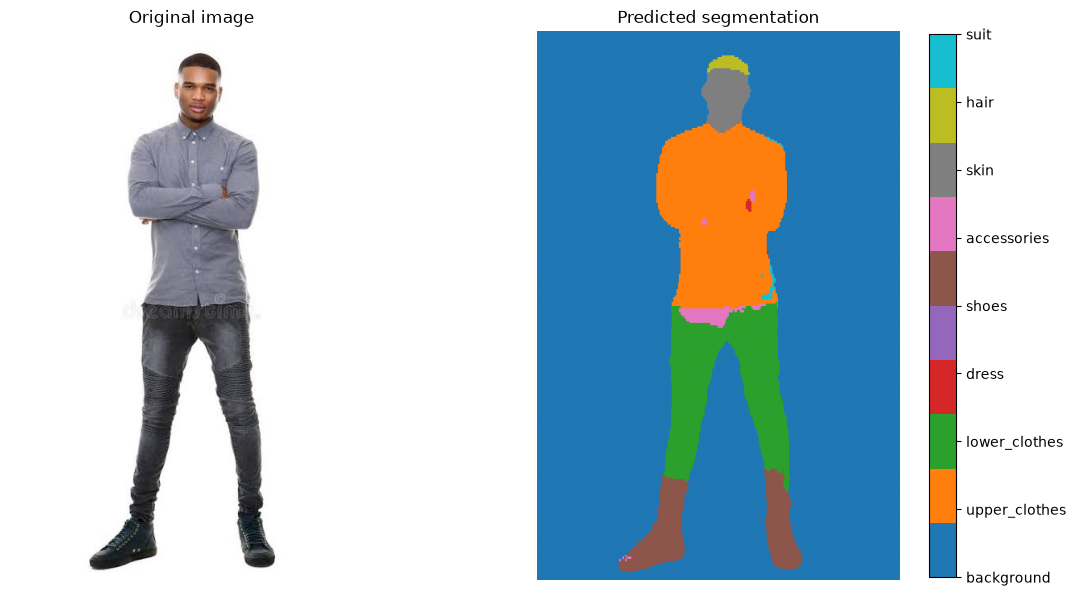

In [5]:
class_names = load_superclass_names()

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].imshow(cv2.cvtColor(original_bgr, cv2.COLOR_BGR2RGB))
axes[0].set_title("Original image")
axes[0].axis("off")

im = axes[1].imshow(pred_mask, cmap="tab10", vmin=0, vmax=config.NUM_CLASSES - 1)
axes[1].set_title("Predicted segmentation")
axes[1].axis("off")

cbar = plt.colorbar(im, ax=axes[1], ticks=range(config.NUM_CLASSES), fraction=0.046)
cbar.ax.set_yticklabels(class_names)

plt.tight_layout()
plt.show()

## Overlay view

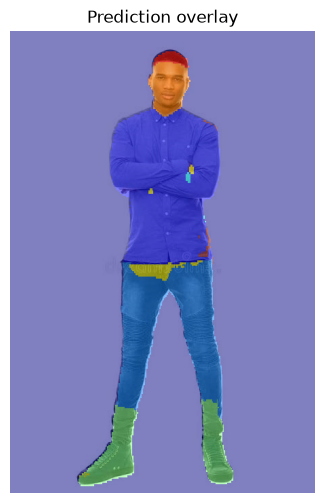

In [7]:
from inference import make_overlay

overlay = make_overlay(original_bgr, pred_mask)
plt.figure(figsize=(6, 6))
plt.imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
plt.title("Prediction overlay")
plt.axis("off")
plt.show()